# Raw reads QC (10x snRNA-seq FASTQs)


**Data:** `/data2/nhartwick/law_lab_myb41_scrna/rawreads` 

| Sample | FASTQ prefix | Role |
|---|---|---|
| Col-0 | `Col-0_S1_L003` | wild-type control |
| pFACT-MYB41 | `pFACT-MYB41_S2_L003` | FACT construct |
| pHORST-MYB41 | `pHORST-MYB41_S3_L003` | HORST construct |

Notes : 
Each sample has 
R1 (barcode+UMI, 28 bp), 
R2 (cDNA, 90 bp), 
I1/I2 (indices, ID).

In [ ]:
#Imports 
import os, gzip

In [ ]:
#LOAD SAMPLES
RAW = "/data2/nhartwick/law_lab_myb41_scrna/rawreads"
SAMPLES = {
    "Col-0":        "Col-0_S1_L003",
    "pFACT-MYB41":  "pFACT-MYB41_S2_L003",
    "pHORST-MYB41": "pHORST-MYB41_S3_L003",
}

In [ ]:
# fastq file
#@read_id            ← line 0  (header)
#ACGTACGT...         ← line 1  (the SEQUENCE)
#+                   ← line 2  (separator)
#FFFF:F,FF...        ← line 3  (the QUALITY string, one ASCII char per base)

def stream_fastq(path, n):
    """Return (seqs, quals) for the first n reads."""
    seqs, quals = [], []
    with gzip.open(path, "rt") as fh:
        for i, line in enumerate(fh):
            m = i % 4
            if m == 1: seqs.append(line.rstrip("\n"))
            elif m == 3: quals.append(line.rstrip("\n"))
            if len(seqs) >= n and m == 3: break
    return seqs, quals

## The four reads in a 10x run (R1, R2, I1, I2)

IN 10x 3′ GEX  Each sequenced fragment produces **four** reads. Two carry the data, two are the sample indices:

| Read | Length | Contains | Purpose |
|------|--------|----------|---------|
| **R1** | 28 bp | 16 bp cell barcode + 12 bp UMI | *which nucleus* (barcode) and *which molecule* (UMI) |
| **R2** | 90 bp | cDNA insert | *the transcript* — the actual gene-expression signal |
| **I1** | 10 bp | i7 sample index | *which sample* (used to demultiplex pooled samples) |
| **I2** | 10 bp | i5 sample index | *which sample* (paired with i7) |

R1 = "who / which copy", R2 = "what", I1+I2 = "which sample". Only R2 carries the biology.


/data1/tmp/ipykernel_708729/568858430.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{t}\n({ROLE[t]})" for t in READ_TYPES])


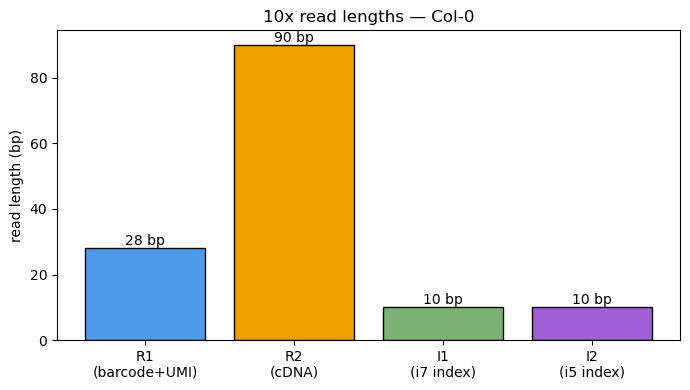

R1: 28 bp   (barcode+UMI)
R2: 90 bp   (cDNA)
I1: 10 bp   (i7 index)
I2: 10 bp   (i5 index)


In [ ]:
# checks the read length of each section
import numpy as np
import matplotlib.pyplot as plt

# path helper for any read type (R1/R2/I1/I2)
def read_file(sample_prefix, tag):
    return f"{RAW}/{sample_prefix}_{tag}_001.fastq.gz"

READ_TYPES = ["R1", "R2", "I1", "I2"]
ROLE = {"R1": "barcode+UMI", "R2": "cDNA", "I1": "i7 index", "I2": "i5 index"}

sample = "Col-0"                      # change to any key in SAMPLES
pref   = SAMPLES[sample]

# read a small subsample from each file and record read lengths (lengths are fixed, so 5k is plenty)
lengths = {}
for tag in READ_TYPES:
    seqs, _ = stream_fastq(read_file(pref, tag), 5000)
    lengths[tag] = [len(s) for s in seqs]

# bar chart: read length (bp) per read type
fig, ax = plt.subplots(figsize=(7, 4))
means = [np.mean(lengths[t]) for t in READ_TYPES]
colors = ["#4c9be8", "#f0a202", "#7bb274", "#a05fd6"]
bars = ax.bar(READ_TYPES, means, color=colors, edgecolor="black")
for b, m in zip(bars, means):
    ax.text(b.get_x() + b.get_width()/2, m + 1, f"{int(m)} bp", ha="center", fontsize=10)
ax.set_ylabel("read length (bp)")
ax.set_title(f"10x read lengths — {sample}")
ax.set_xticklabels([f"{t}\n({ROLE[t]})" for t in READ_TYPES])
plt.tight_layout()
plt.show()

for t in READ_TYPES:
    print(f"{t}: {int(np.mean(lengths[t]))} bp   ({ROLE[t]})")


## Setup

In [ ]:
import os, gzip
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RAW = "/data2/nhartwick/law_lab_myb41_scrna/rawreads"
# SAMPLES = {
#     "Col-0":        "Col-0_S1_L003",
#     "pFACT-MYB41":  "pFACT-MYB41_S2_L003",
#     "pHORST-MYB41": "pHORST-MYB41_S3_L003",
# }
N_READS = 200_000     # representative reads to subsample per file.

def r1(s): return f"{RAW}/{s}_R1_001.fastq.gz"
def r2(s): return f"{RAW}/{s}_R2_001.fastq.gz"

# def stream_fastq(path, n):
#     """Return (seqs, quals) for the first n reads."""
#     seqs, quals = [], []
#     with gzip.open(path, "rt") as fh:
#         for i, line in enumerate(fh):
#             m = i % 4
#             if m == 1: seqs.append(line.rstrip("\n"))
#             elif m == 3: quals.append(line.rstrip("\n"))
#             if len(seqs) >= n and m == 3: break
#     return seqs, quals

def phred(qual_str):
    return [ord(c) - 33 for c in qual_str]

for name, pref in SAMPLES.items():
    files = {tag: os.path.exists(f"{RAW}/{pref}_{tag}_001.fastq.gz")
             for tag in ["R1", "R2", "I1", "I2"]}
    if all(files.values()):
        print(f"{name:14} OK       — all 4 read files (R1/R2/I1/I2) found")
    else:
        missing = [t for t, ok in files.items() if not ok]
        print(f"{name:14} MISSING  — {', '.join(missing)}")

print(f"\nsubsampling {N_READS:,} reads per file")

Col-0          OK       — all 4 read files (R1/R2/I1/I2) found
pFACT-MYB41    OK       — all 4 read files (R1/R2/I1/I2) found
pHORST-MYB41   OK       — all 4 read files (R1/R2/I1/I2) found

subsampling 200,000 reads per file


## File inventory & read structure

In [ ]:
rows = []
for name, pref in SAMPLES.items():
    for tag, path in [("R1", r1(pref)), ("R2", r2(pref))]:
        sz = os.path.getsize(path) / 1e9
        s, q = stream_fastq(path, 1)      # peek one read for length
        rows.append({"sample": name, "read": tag, "size_GB": round(sz,1),
                     "read_len": len(s[0])})
inv = pd.DataFrame(rows)
print(inv.to_string(index=False))
print("\nExpected: R1 = 28 bp (16 bp barcode + 12 bp UMI), R2 = 90 bp (cDNA)")


Col-0 Col-0_S1_L003
pFACT-MYB41 pFACT-MYB41_S2_L003
pHORST-MYB41 pHORST-MYB41_S3_L003
      sample read  size_GB  read_len
       Col-0   R1      8.1        28
       Col-0   R2     15.2        90
 pFACT-MYB41   R1      9.1        28
 pFACT-MYB41   R2     17.4        90
pHORST-MYB41   R1      8.8        28
pHORST-MYB41   R2     16.5        90

Expected: R1 = 28 bp (16 bp barcode + 12 bp UMI), R2 = 90 bp (cDNA)


## Load subsamples

In [16]:
data = {}   # name -> dict(r1_seq, r1_qual, r2_seq, r2_qual)
for name, pref in SAMPLES.items():
    s1, q1 = stream_fastq(r1(pref), N_READS)
    s2, q2 = stream_fastq(r2(pref), N_READS)
    data[name] = {"r1_seq": s1, "r1_qual": q1, "r2_seq": s2, "r2_qual": q2}
    print(f"{name:14}: loaded {len(s1):,} R1 and {len(s2):,} R2 reads")


Col-0         : loaded 200,000 R1 and 200,000 R2 reads
pFACT-MYB41   : loaded 200,000 R1 and 200,000 R2 reads
pHORST-MYB41  : loaded 200,000 R1 and 200,000 R2 reads


In [ ]:
#Tota cells in the fastq files.


In [ ]:
import gzip, scipy.io, numpy as np, matplotlib.pyplot as plt
SAMPLE_OUTS = "/data1/bfernando/DE_project/Col-0_v4/outs" 

def load_umi(mtx_dir):
    """Return (barcodes, total_UMI_per_barcode) from a 10x matrix folder."""
    with gzip.open(f"{mtx_dir}/matrix.mtx.gz") as fh:
        M = scipy.io.mmread(fh).tocsc()               # genes x barcodes
    bcs = np.array([l.strip() for l in gzip.open(f"{mtx_dir}/barcodes.tsv.gz", "rt")])
    umi = np.asarray(M.sum(axis=0)).ravel()            # total UMI per barcode
    return bcs, umi

# these are filtered results where only 864 cells are called.
cell_bcs, cell_umi = load_umi(f"{SAMPLE_OUTS}/filtered_feature_bc_matrix")
raw_bcs,  raw_umi  = load_umi(f"{SAMPLE_OUTS}/raw_feature_bc_matrix")

print("=== CALLED CELLS (filtered) ===")
print(f"  unique cell barcodes : {len(cell_bcs):,}")
print(f"  UMI/cell  min={cell_umi.min():.0f}  max={cell_umi.max():.0f}  "
      f"mean={cell_umi.mean():.0f}  median={np.median(cell_umi):.0f}")

=== CALLED CELLS (filtered) ===
  unique cell barcodes : 864
  UMI/cell  min=502  max=62119  mean=3238  median=1380


Results from the cell above
=== CALLED CELLS (filtered) ===
  unique cell barcodes : 864
  UMI/cell  min=502  max=62119  mean=3238  median=1380

In [24]:
unique cell barcodes : 864
  UMI/cell  min=502  max=62119  mean=3238  median=1380

SyntaxError: invalid syntax (1970882496.py, line 1)

## Step 3 — Per-base sequencing quality

Mean Phred quality at each read position. Q30 (99.9% base-call accuracy) is the usual
"good" threshold. A drop-off tells you where reads get unreliable.


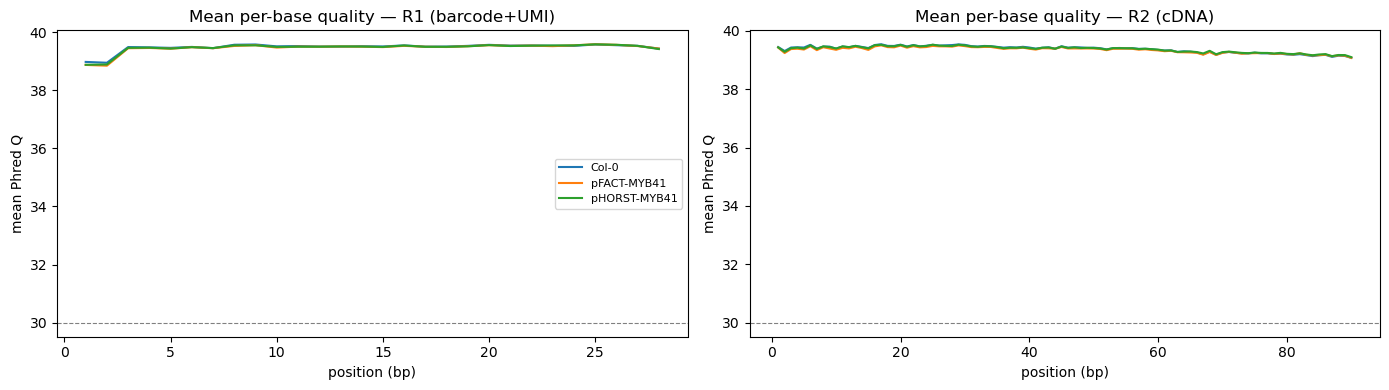

mean Q (whole read):
  Col-0         : R1=39.5  R2=39.4
  pFACT-MYB41   : R1=39.5  R2=39.3
  pHORST-MYB41  : R1=39.5  R2=39.4


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for name in SAMPLES:
    for ax, key, title in [(axes[0], "r1_qual", "R1 (barcode+UMI)"),
                           (axes[1], "r2_qual", "R2 (cDNA)")]:
        arr = np.array([phred(x) for x in data[name][key]])
        ax.plot(range(1, arr.shape[1]+1), arr.mean(axis=0), label=name)
        ax.set_title(f"Mean per-base quality — {title}")
        ax.set_xlabel("position (bp)"); ax.set_ylabel("mean Phred Q")
axes[0].axhline(30, color="grey", ls="--", lw=0.8)
axes[1].axhline(30, color="grey", ls="--", lw=0.8)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

# summary table
print("mean Q (whole read):")
for name in SAMPLES:
    q1 = np.mean([np.mean(phred(x)) for x in data[name]["r1_qual"]])
    q2 = np.mean([np.mean(phred(x)) for x in data[name]["r2_qual"]])
    print(f"  {name:14}: R1={q1:.1f}  R2={q2:.1f}")


## Step 4 — Per-base composition of R2 (cDNA)

Fraction of A/C/G/T/N at each position of the cDNA read. Flags problems like:
high **N** (uncalled bases), extreme **GC** skew, or a dominant base (e.g. poly-A/poly-G
runs = low-complexity artifacts). Healthy cDNA should look roughly balanced.


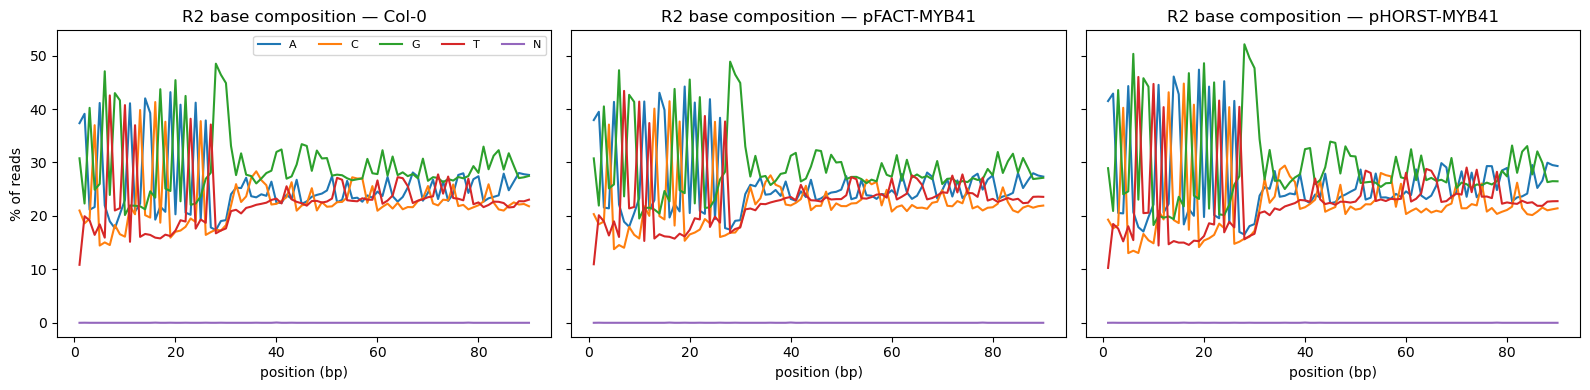

Overall R2 base fractions (%):
  Col-0         : A=25.5 C=22.6 G=29.4 T=22.5 N=0.00  GC=52.0%
  pFACT-MYB41   : A=25.8 C=22.2 G=29.0 T=23.0 N=0.00  GC=51.3%
  pHORST-MYB41  : A=26.1 C=22.1 G=29.1 T=22.7 N=0.00  GC=51.2%


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, name in zip(axes, SAMPLES):
    seqs = data[name]["r2_seq"]
    L = max(len(s) for s in seqs)
    comp = {b: np.zeros(L) for b in "ACGTN"}
    tot = np.zeros(L)
    for s in seqs:
        for i, ch in enumerate(s):
            comp.get(ch, comp["N"])[i] += 1
            tot[i] += 1
    for b in "ACGTN":
        ax.plot(range(1, L+1), 100*comp[b]/np.maximum(tot,1), label=b)
    ax.set_title(f"R2 base composition — {name}"); ax.set_xlabel("position (bp)")
axes[0].set_ylabel("% of reads"); axes[0].legend(fontsize=8, ncol=5)
plt.tight_layout(); plt.show()

print("Overall R2 base fractions (%):")
for name in SAMPLES:
    c = Counter("".join(data[name]["r2_seq"]))
    tot = sum(c.values())
    gc = 100*(c["G"]+c["C"])/tot
    print(f"  {name:14}: A={100*c['A']/tot:.1f} C={100*c['C']/tot:.1f} "
          f"G={100*c['G']/tot:.1f} T={100*c['T']/tot:.1f} N={100*c['N']/tot:.2f}  GC={gc:.1f}%")


## Step 5 — Chemistry check (barcode whitelist match)

Confirms which 10x kit generated the data by matching the R1 cell barcode (first 16 bp)
against Cell Ranger's whitelists. The winning whitelist = the chemistry. (Also gives the
"valid barcode" rate from raw reads — Cell Ranger error-corrects, so its number is higher.)


In [21]:
BCDIR = "/data1/bfernando/software/cellranger/cellranger-10.1.0/lib/python/cellranger/barcodes/"
WL = {"3' v2":"737K-august-2016.txt.gz", "3' v3":"3M-february-2018_TRU.txt.gz",
      "3' v4 / GEM-X":"3M-3pgex-may-2023_TRU.txt.gz", "5'":"3M-5pgex-jan-2023.txt.gz",
      "Multiome/ARC":"737K-arc-v1.txt.gz"}
wl_sets = {}
for nm, fn in WL.items():
    p = os.path.join(BCDIR, fn)
    if os.path.exists(p):
        wl_sets[nm] = {l.split()[0] for l in gzip.open(p, "rt")}

rows=[]
for name in SAMPLES:
    bcs = [s[:16] for s in data[name]["r1_seq"]]
    row = {"sample": name}
    for nm, s in wl_sets.items():
        row[nm] = round(100*sum(b in s for b in bcs)/len(bcs), 1)
    rows.append(row)
match = pd.DataFrame(rows).set_index("sample")
print("Barcode match rate (%) vs each whitelist:")
print(match.to_string())
print("\n-> highest column = the chemistry (expected: 3' v4 / GEM-X)")


Barcode match rate (%) vs each whitelist:
              3' v3  3' v4 / GEM-X   5'  Multiome/ARC
sample                                               
Col-0           0.5           78.3  5.6           0.0
pFACT-MYB41     0.5           77.9  5.5           0.0
pHORST-MYB41    0.5           78.1  4.9           0.0

-> highest column = the chemistry (expected: 3' v4 / GEM-X)


## Step 6 — Barcode & UMI diversity

From the subsample: how many distinct cell barcodes and UMIs, and the reads-per-barcode
distribution. A steep reads-per-barcode drop hints at a few high-coverage barcodes (real
nuclei) over a sea of low-count background — related to Cell Ranger's cell-calling.


sample          distinct BC  distinct UMI  reads/BC(top1%)
Col-0                92,284       133,085             31.1
pFACT-MYB41          95,298       137,209             34.3
pHORST-MYB41         76,967       132,097             64.6


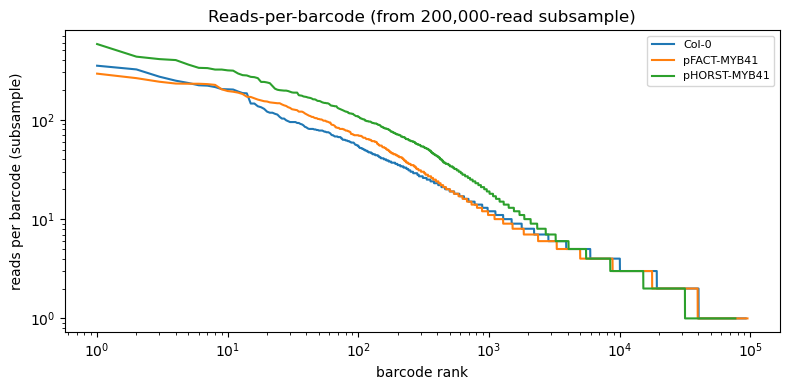


Note: this is a SUBSAMPLE-based curve (shape only). The definitive barcode-rank /
cell-calling knee is in Cell Ranger's web_summary.html.


In [22]:
fig, ax = plt.subplots(figsize=(8,4))
print(f"{'sample':14} {'distinct BC':>12} {'distinct UMI':>13} {'reads/BC(top1%)':>16}")
for name in SAMPLES:
    bcs = [s[:16] for s in data[name]["r1_seq"]]
    umis = [s[16:28] for s in data[name]["r1_seq"]]
    bc_counts = Counter(bcs)
    counts = np.array(sorted(bc_counts.values(), reverse=True))
    top1 = counts[:max(1,len(counts)//100)].mean()
    print(f"{name:14} {len(bc_counts):>12,} {len(set(umis)):>13,} {top1:>16.1f}")
    ax.loglog(range(1, len(counts)+1), counts, label=name)
ax.set_xlabel("barcode rank"); ax.set_ylabel("reads per barcode (subsample)")
ax.set_title(f"Reads-per-barcode (from {N_READS:,}-read subsample)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print("\nNote: this is a SUBSAMPLE-based curve (shape only). The definitive barcode-rank /")
print("cell-calling knee is in Cell Ranger's web_summary.html.")


## Step 7 — Hunt for contamination / low-complexity artifacts

High multi-mapping + low intronic in the Cell Ranger QC can be caused by rRNA, adapter,
or poly-A/low-complexity reads. Here we look at the most **overrepresented R2 sequences**
and the fraction of low-complexity reads. A single dominant sequence (that you can BLAST)
often explains multi-mapping.


In [23]:
def low_complexity(seq, frac=0.8):
    if not seq: return False
    c = Counter(seq)
    return max(c.values())/len(seq) >= frac      # >=80% a single base

for name in SAMPLES:
    seqs = data[name]["r2_seq"]
    # most common 30-mer prefixes
    top = Counter(s[:30] for s in seqs).most_common(5)
    lc = 100*np.mean([low_complexity(s) for s in seqs])
    polyA = 100*np.mean([s.count("A")/max(len(s),1) >= 0.8 for s in seqs])
    print(f"=== {name} ===")
    print(f"  low-complexity reads (>=80% one base): {lc:.1f}%   |   poly-A-like (>=80% A): {polyA:.1f}%")
    print(f"  top R2 30-bp prefixes (count / {len(seqs):,}):")
    for seq, n in top:
        print(f"    {n:>7,}  {seq}")
    print()


=== Col-0 ===
  low-complexity reads (>=80% one base): 0.3%   |   poly-A-like (>=80% A): 0.0%
  top R2 30-bp prefixes (count / 200,000):
     40,517  AAGCAGTGGTATCAACGCAGAGTACATGGG
      2,055  AGCAGTGGTATCAACGCAGAGTACATGGGG
      1,665  GCAGTGGTATCAACGCAGAGTACATGGGGC
        873  AGCAGTGGTATCAACGCAGAGTACATGGGA
        705  GCAGTGGTATCAACGCAGAGTACATGGGGA

=== pFACT-MYB41 ===
  low-complexity reads (>=80% one base): 0.3%   |   poly-A-like (>=80% A): 0.0%
  top R2 30-bp prefixes (count / 200,000):
     41,456  AAGCAGTGGTATCAACGCAGAGTACATGGG
      2,163  AGCAGTGGTATCAACGCAGAGTACATGGGG
      1,723  GCAGTGGTATCAACGCAGAGTACATGGGGC
        966  GCAGTGGTATCAACGCAGAGTACATGGGGA
        861  AGCAGTGGTATCAACGCAGAGTACATGGGA

=== pHORST-MYB41 ===
  low-complexity reads (>=80% one base): 0.2%   |   poly-A-like (>=80% A): 0.0%
  top R2 30-bp prefixes (count / 200,000):
     49,215  AAGCAGTGGTATCAACGCAGAGTACATGGG
      2,460  AGCAGTGGTATCAACGCAGAGTACATGGGG
      2,103  GCAGTGGTATCAACGCAGAGTACATGGGGC
  

## Summary — what the raw reads tell us

Fill in after running:

- **Chemistry:** confirmed (Step 5) — highest whitelist match.
- **Sequencing quality:** R1/R2 mean Q (Step 3) — is it >Q30?
- **Composition:** any N spikes, GC skew, or low-complexity dominance (Steps 4, 7)?
- **Contamination:** any overrepresented R2 sequence (Step 7) that could explain the high
  multi-mapping seen in Cell Ranger? (BLAST the top sequence to identify it — e.g. rRNA.)
- **Barcodes:** distinct-barcode counts and reads-per-barcode shape (Step 6).

These read-level observations are independent of the reference/alignment, so they isolate
whether the QC concerns come from the **library/reads** vs. the **mapping**.
